# Final Project Report: Waste Image Classification with CNN + Grad-CAM Attention
## LINK GITHUB: https://github.com/ne-he/Image-Classification-DL.git

Untuk codingan nomor 1 yg projek kelompok jg aku taro di IPYNB sebelah pak, juga sudah di push ke github

**Dataset:** TrashNet (Cardboard, Glass, Metal, Paper, Plastic, Trash)  
**Approach:** Transfer Learning with MobileNetV2 + Grad-CAM Explainability  
**Framework:** TensorFlow / Keras

# Nomor 1 —  Final Project Report (Waste Image Classification with CNN and Grad-CAM)

## 1. Preprocessing Methods

The dataset used in this project is TrashNet, which contains 2,527 images across six waste categories: cardboard (403), glass (501), metal (410), paper (594), plastic (482), and trash (137). The original image resolution is 384×512 pixels in RGB format.

Before training, the following preprocessing steps were applied:

**Image Resizing.** All images were resized to 224×224 pixels. This size was chosen because MobileNetV2, the backbone used in the final model, was originally designed to accept inputs of this resolution. Using the same input size allows the pretrained weights to function correctly without additional modifications.

**Normalization.** Pixel values were rescaled from the original range of [0, 255] to [0, 1] by dividing by 255. This step helps the model converge faster and prevents numerical instability during gradient computation.

**Data Splitting.** The dataset was split into 80% training (2,024 images) and 20% validation (503 images) using the `validation_split=0.2` parameter in Keras `ImageDataGenerator`. The split was performed automatically with a fixed seed to ensure reproducibility. Validation data was not shuffled, which is important for consistent evaluation across epochs.

**Data Augmentation.** To reduce overfitting and increase the diversity of the training set, augmentation was applied exclusively to the training generator with the following transformations:
- Random rotation up to ±20 degrees
- Random zoom up to 20%
- Random horizontal flipping

Augmentation was not applied to the validation set, as evaluation should reflect real, unmodified data conditions.

One notable characteristic of this dataset is its class imbalance. The trash class has only 137 images, which is less than a quarter of the paper class (594 images). This imbalance has a direct effect on the model's ability to learn the minority class, as will be seen in the evaluation results.

---

## 2. Model Used and Reason for Choosing It

Two models were built and compared in this project.

**Baseline CNN.** The first model was a standard CNN built from scratch, consisting of three Conv2D + MaxPooling2D blocks with filter sizes of 32, 64, and 128, followed by a fully connected Dense(128) layer with Dropout(0.5) and a softmax output layer with 6 units. This model had approximately 11 million trainable parameters and was trained for 15 epochs.

The baseline was intentionally kept simple to serve as a performance reference. After 15 epochs, it reached a training accuracy of 65.6% and a validation accuracy of 54.5%. The growing gap between training and validation accuracy indicates that the model was starting to overfit, and the validation accuracy plateau showed that the model was struggling to generalize from a dataset of only ~2,500 images.

**MobileNetV2 with Transfer Learning.** Based on the limitations of the baseline, transfer learning was adopted using MobileNetV2 pretrained on ImageNet. The reasons for this choice are:

- MobileNetV2 was trained on ImageNet, which contains over 1.2 million images. The features it has learned — edges, textures, color patterns, shapes — transfer well to waste classification because many of these low-level and mid-level visual features are relevant across domains.
- MobileNetV2 uses depthwise separable convolutions, which makes it significantly more computationally efficient than standard Conv2D while maintaining competitive accuracy.
- With only ~2,500 training images, training a large CNN from scratch is prone to overfitting. Freezing the backbone and only training a lightweight classification head reduces the number of trainable parameters significantly, which is more appropriate for a small dataset.

The final architecture is: MobileNetV2 backbone (frozen, ImageNet weights) → GlobalAveragePooling2D → Dense(128, ReLU) → Dropout(0.5) → Dense(6, softmax).

The model was compiled with the Adam optimizer, categorical crossentropy loss, and accuracy as the evaluation metric.

---

## 3. Training and Validation Results

**Baseline CNN (15 epochs):**

| Epoch | Train Accuracy | Val Accuracy | Train Loss | Val Loss |
|-------|---------------|-------------|-----------|---------|
| 1 | 26.33% | 35.98% | 1.9094 | 1.5463 |
| 5 | 48.12% | 46.12% | 1.3050 | 1.3514 |
| 10 | 60.13% | 52.49% | 1.0614 | 1.3048 |
| 15 | 65.56% | 54.47% | 0.9297 | 1.2125 |

The baseline model showed steady improvement in training accuracy, but validation accuracy plateaued around 54-55% after epoch 10. The increasing gap between training loss (0.93) and validation loss (1.21) at the final epoch is a clear sign of overfitting. The model was learning patterns specific to the training images rather than generalizing.

**MobileNetV2 Transfer Learning (14 epochs, stopped early):**

| Epoch | Train Accuracy | Val Accuracy | Train Loss | Val Loss |
|-------|---------------|-------------|-----------|---------|
| 1 | 58.70% | 67.20% | 1.1022 | 0.8167 |
| 3 | 77.82% | 73.96% | 0.6178 | 0.6341 |
| 6 | 83.65% | 75.15% | 0.4591 | 0.6091 |
| 9 | 87.15% | 77.14% | 0.3588 | 0.6038 |
| 13 | 90.86% | 77.73% | 0.2464 | 0.6172 |
| 14 | 91.60% | 77.53% | 0.2301 | 0.6230 |

Training stopped at epoch 14 due to EarlyStopping (patience=5), and weights were restored from epoch 9, which had the best validation loss (0.6038). ReduceLROnPlateau triggered at epoch 12, reducing the learning rate from 0.001 to 0.0005.

MobileNetV2 achieved 67.2% validation accuracy from the very first epoch, which is already higher than the baseline's final result. This is a direct effect of transfer learning — the backbone already contained useful feature representations before any training began.

The final reported validation accuracy is 77.14% (epoch 9, best weights restored). Transfer learning improved validation accuracy by approximately 22.7 percentage points compared to the baseline CNN.

---

## 4. Evaluation Results

The final MobileNetV2 model was evaluated on the 503-image validation set. The following results were obtained:

**Overall accuracy: 77.14%**

**Per-class classification report:**

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| cardboard | 0.9375 | 0.7500 | 0.8333 | 80 |
| glass | 0.7604 | 0.7300 | 0.7449 | 100 |
| metal | 0.7527 | 0.8537 | 0.8000 | 82 |
| paper | 0.8182 | 0.9153 | 0.8640 | 118 |
| plastic | 0.6635 | 0.7188 | 0.6900 | 96 |
| trash | 0.5714 | 0.2963 | 0.3902 | 27 |
| macro avg | 0.7506 | 0.7107 | 0.7204 | 503 |

**Per-class AUC scores:**

| Class | AUC |
|-------|-----|
| cardboard | 0.9831 |
| glass | 0.9475 |
| metal | 0.9720 |
| paper | 0.9807 |
| plastic | 0.9394 |
| trash | 0.9427 |
| Macro AUC | 0.9617 |

**Analysis of results:**

Paper achieved the highest F1-score (0.864), with particularly strong recall at 0.915. This is consistent with paper being the largest class in the dataset (594 images) and having fairly consistent visual characteristics — flat, rectangular, often with printed text.

Cardboard had the highest precision (0.9375), meaning when the model predicted cardboard, it was almost always correct. However, its recall was 0.75, indicating the model missed 25% of actual cardboard samples. Some cardboard items were likely misclassified as paper due to visual similarity in texture and color.

Metal and glass both achieved solid F1-scores (0.80 and 0.74 respectively), with metal having notably high recall (0.854). The Grad-CAM visualization confirmed the model focused on relevant features — metallic surfaces and cylindrical shapes for metal, transparent surfaces and bottle silhouettes for glass.

Plastic had a moderate F1-score of 0.69. From the Grad-CAM output, one plastic bottle sample was misclassified as glass with 69% confidence, which is understandable given that transparent plastic bottles and glass bottles are visually very similar without texture information at this scale.

Trash had the weakest performance by a significant margin, with an F1-score of only 0.39 and recall of only 0.296. This means the model correctly identified less than 30% of actual trash items. This is primarily caused by two factors: first, the trash class is severely underrepresented with only 137 images (27 in the validation set), giving the model very few examples to learn from; second, the trash class is inherently heterogeneous — it contains items that could visually resemble any of the other categories, making it fundamentally harder to separate.

Despite the weakness in the trash class, the macro AUC of 0.9617 indicates that the model has strong discriminative ability across all classes when examined from a probabilistic perspective. Even for trash, the AUC of 0.9427 suggests the model's confidence scores are well-calibrated.

---

## 5. Existing Challenges and Future Opportunities

**Challenge 1: Class imbalance.** The trash class contains only 137 images compared to 594 for paper. This imbalance directly caused the model to underperform on the minority class, achieving only 29.6% recall for trash. Simply having more data for this class would likely be the single most impactful improvement.

**Challenge 2: Visual ambiguity between classes.** Several waste categories share visual properties that make them difficult to separate. Transparent plastic and glass bottles look nearly identical at 224×224 resolution. Flattened cardboard and paper can be indistinguishable without tactile or contextual information. This is a fundamental limitation of purely visual classification.

**Challenge 3: Generalization gap.** By epoch 14, training accuracy reached 91.6% while validation accuracy was 77.5% — a gap of about 14 percentage points. Although the model did not overfit severely (EarlyStopping and Dropout helped), this gap suggests there is still room to improve generalization.

**Challenge 4: Frozen backbone limitation.** Keeping MobileNetV2 fully frozen means the model relies entirely on ImageNet features, which were learned on a very different distribution (natural images, animals, objects) compared to waste classification. Some domain-specific features may not be well represented in the frozen weights.

**Future opportunity 1: Fine-tuning.** After training the classification head, the upper layers of MobileNetV2 could be unfrozen and trained with a very small learning rate (e.g., 1e-5). This would allow the model to adapt some of its deeper feature representations specifically to waste imagery, potentially closing the generalization gap.

**Future opportunity 2: Addressing class imbalance.** Several approaches could help with the trash class specifically: collecting more diverse trash images, applying class-weighted loss during training (`class_weight` parameter in Keras), or using targeted augmentation to artificially increase the trash class representation.

**Future opportunity 3: Stronger backbone.** MobileNetV2 was chosen for its efficiency, but models like EfficientNetB3 or ResNet50V2 may extract richer features at the cost of slightly higher computation. These could be tested as drop-in replacements for the backbone.

**Future opportunity 4: Deployment with Grad-CAM.** The Grad-CAM visualization demonstrated that the model focuses on semantically meaningful regions. This has practical value — in a real waste sorting system, operators could use the heatmap overlay to verify model decisions before acting, making the system more trustworthy and auditable.


# Nomor 2 — RNN Time-Series Forecasting: Stock Price Prediction

**Dataset:** US Stocks & ETFs Historical Daily Prices (Kaggle)  
**Task:** Predict next day's closing price (output sequence length = 1)  
**Model:** Stacked LSTM with 2 recurrent layers + 5 input covariates  
**Framework:** TensorFlow / Keras

> **How to use this notebook:**
> 1. Run cell pertama untuk install & import
> 2. Run cell **"Load Dataset"** → pilih salah satu file `.txt` dari dataset (misal `aapl.us.txt`)
> 3. Jalankan semua cell selanjutnya secara berurutan

## 0. Install & Import Libraries

In [ ]:
# Install dependencies (jalankan sekali di Colab)
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings, io, os
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print("Semua library berhasil diimport")

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2
Semua library berhasil diimport


## 1. Load Dataset

Upload salah satu file `.txt` dari dataset Kaggle US Stocks/ETFs.  
Format file: `Date, Open, High, Low, Close, Volume, OpenInt`

> **Cara upload:**  
> Jalankan cell di bawah → klik tombol **"Choose Files"** → pilih file `.txt` (misal `aapl.us.txt` atau `msft.us.txt`)

In [ ]:
import requests
import zipfile
from io import BytesIO
import pandas as pd

# Configuration
BASE_URL = "https://mdl3jdvn-8000.asse.devtunnels.ms/archive%20(2)/"
# Silakan ganti ticker di bawah ini (misal: 'aapl', 'tsla', 'msft')
SELECTED_TICKER = 'aapl'

def load_stock_data(ticker):
    ticker = ticker.lower()
    paths_to_try = [
        f"Data/Stocks/{ticker}.us.txt",
        f"Data/ETFs/{ticker}.us.txt",
        f"Stocks/{ticker}.us.txt",
        f"ETFs/{ticker}.us.txt"
    ]

    for path in paths_to_try:
        full_url = f"{BASE_URL}{path}"
        print(f"Mencoba mengakses: {full_url}...")
        try:
            response = requests.get(full_url, timeout=10)
            if response.status_code == 200:
                print(f"✓ Berhasil menemukan data untuk {ticker.upper()}")
                df = pd.read_csv(
                    BytesIO(response.content),
                    parse_dates=['Date'],
                    index_col='Date'
                )
                return df, ticker.upper()
        except Exception as e:
            continue

    raise FileNotFoundError(f"Ticker {ticker} tidak ditemukan di direktori remote.")

try:
    df_raw, stock_name = load_stock_data(SELECTED_TICKER)

    # Lowercase kolom biar konsisten
    df_raw.columns = [c.strip().title() for c in df_raw.columns]

    print(f"\nTicker  : {stock_name}")
    print(f"Shape   : {df_raw.shape}")
    print(f"Periode : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
    print(f"\nPreview data:")
    display(df_raw.head())
except Exception as e:
    print(f"Gagal memuat data: {e}")
    print("Pastikan link aktif dan ticker tersedia di server.")

Mencoba mengakses: https://mdl3jdvn-8000.asse.devtunnels.ms/archive%20(2)/Data/Stocks/aapl.us.txt...
✓ Berhasil menemukan data untuk AAPL

Ticker  : AAPL
Shape   : (8364, 6)
Periode : 1984-09-07 → 2017-11-10

Preview data:


,Open,High,Low,Close,Volume,Openint
Date,,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


## 2. Exploratory Data Analysis (EDA)

Sebelum membangun model, kita perlu memahami karakteristik data:
- **Trend jangka panjang** harga saham
- **Pola seasonality** berdasarkan bulan/tahun
- **Volatilitas** dan distribusi return harian
- **Korelasi antar fitur**

In [ ]:
print("="*50)
print(f"STATISTIK DESKRIPTIF — {stock_name}")
print("="*50)
print(df_raw[['Open','High','Low','Close','Volume']].describe().round(2))
print(f"\nJumlah data  : {len(df_raw):,} hari trading")
print(f"Missing values: {df_raw.isnull().sum().sum()}")

STATISTIK DESKRIPTIF — AAPL
          Open     High      Low    Close        Volume
count  8364.00  8364.00  8364.00  8364.00  8.364000e+03
mean     22.28    22.50    22.05    22.28  1.066416e+08
std      37.76    38.06    37.45    37.76  9.935187e+07
min       0.23     0.24     0.23     0.23  0.000000e+00
25%       1.14     1.16     1.11     1.14  4.384365e+07
50%       1.63     1.66     1.60     1.63  7.481383e+07
75%      23.74    23.93    23.34    23.69  1.320534e+08
max     175.11   175.61   174.27   175.61  2.069770e+09

Jumlah data  : 8,364 hari trading
Missing values: 0


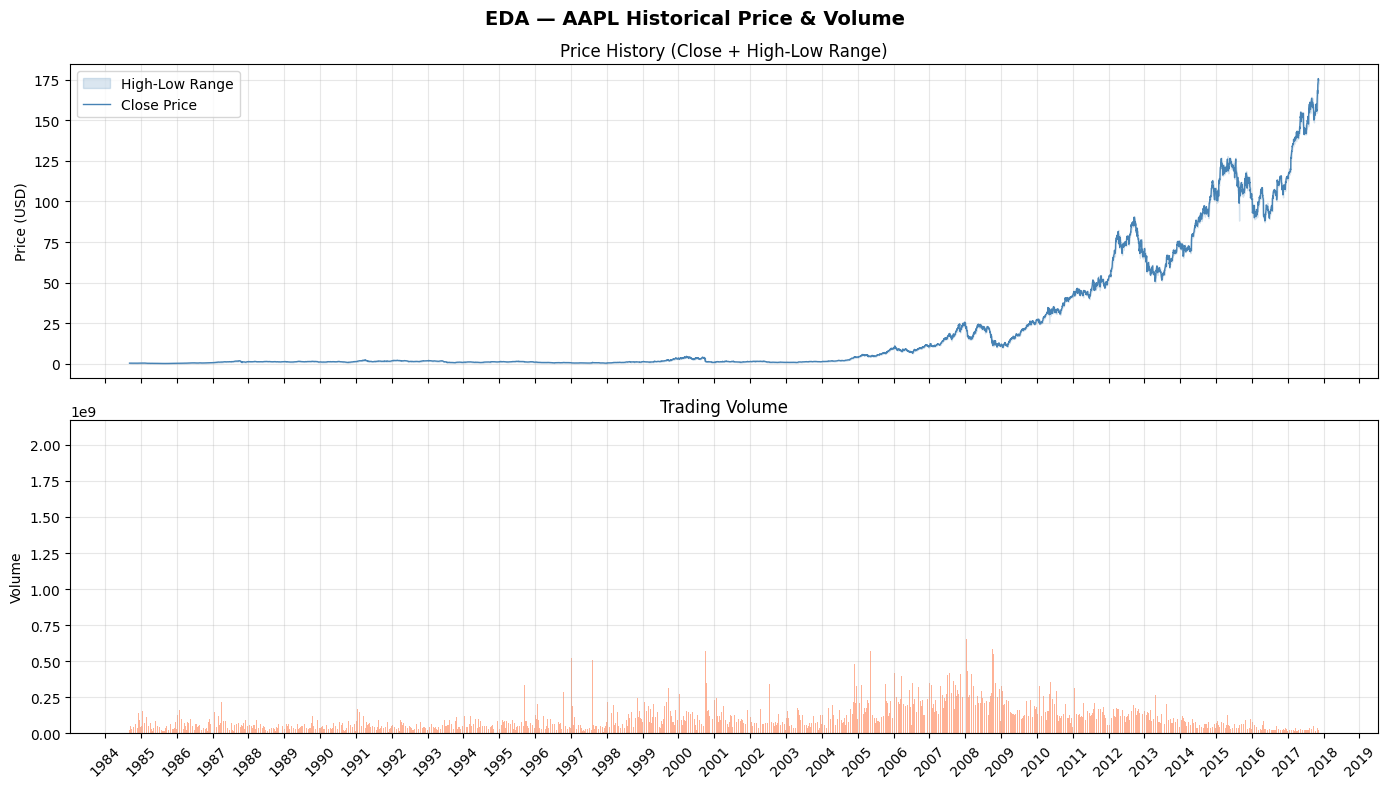

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'EDA — {stock_name} Historical Price & Volume',
             fontsize=14, fontweight='bold')

# Candlestick-style: High/Low range + Close
axes[0].fill_between(df_raw.index, df_raw['Low'], df_raw['High'],
                     alpha=0.2, color='steelblue', label='High-Low Range')
axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue',
             linewidth=1.0, label='Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Price History (Close + High-Low Range)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df_raw.index, df_raw['Volume'], color='coral', alpha=0.6, width=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Trading Volume')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df = df_raw[['Open','High','Low','Close','Volume']].copy()

df['MA7']          = df['Close'].rolling(7).mean()
df['MA30']         = df['Close'].rolling(30).mean()
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility']   = df['Daily_Return'].rolling(14).std()
df['HL_Range']     = (df['High'] - df['Low']) / df['Close']  # intraday range %

df.dropna(inplace=True)

print(f"Shape setelah feature engineering: {df.shape}")
print(f"Fitur yang tersedia: {df.columns.tolist()}")
print(df.head(3).round(4))

Shape setelah feature engineering: (8335, 10)
Fitur yang tersedia: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30', 'Daily_Return', 'Volatility', 'HL_Range']
              Open    High     Low   Close    Volume     MA7    MA30  \
Date                                                                   
1984-10-18  0.4085  0.4111  0.4085  0.4085  68929180  0.3847  0.4101   
1984-10-19  0.4085  0.4367  0.4072  0.4085  90949795  0.3886  0.4096   
1984-10-22  0.4085  0.4149  0.4059  0.4059  32003288  0.3924  0.4091   

            Daily_Return  Volatility  HL_Range  
Date                                            
1984-10-18        0.0291      0.0277    0.0063  
1984-10-19        0.0000      0.0269    0.0721  
1984-10-22       -0.0064      0.0270    0.0221  


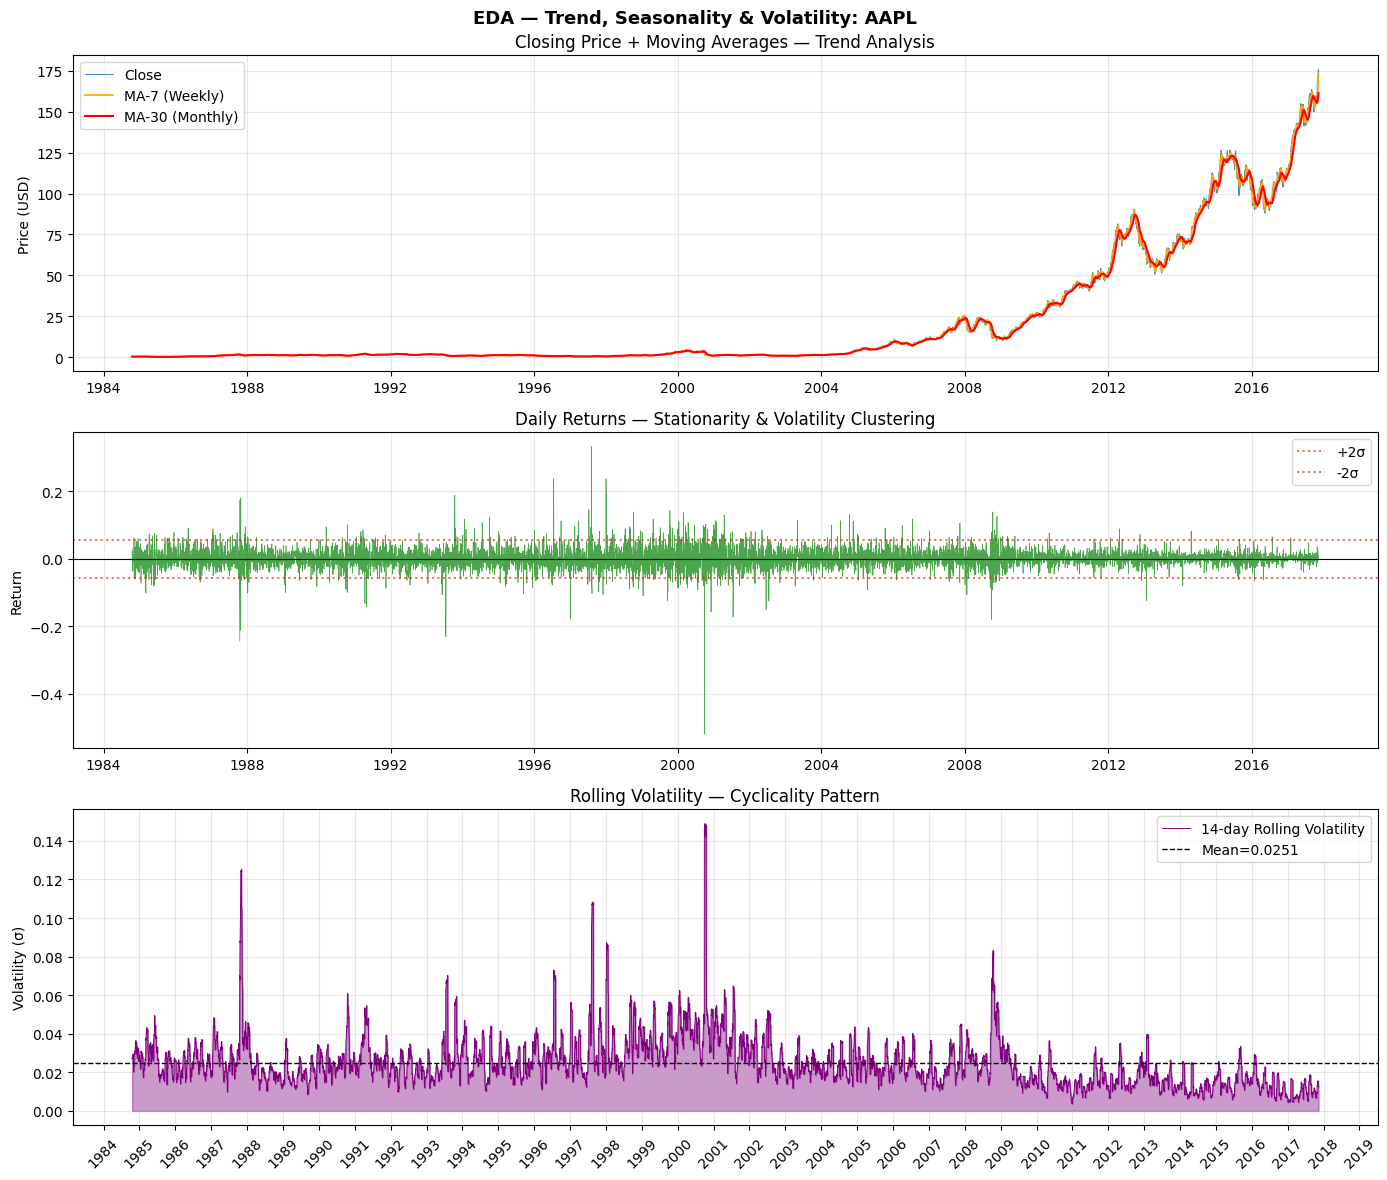

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f'EDA — Trend, Seasonality & Volatility: {stock_name}',
             fontsize=13, fontweight='bold')

# Panel 1: Close + Moving Averages (Trend)
ax = axes[0]
ax.plot(df.index, df['Close'],  color='#1f77b4', linewidth=0.8, alpha=0.8, label='Close')
ax.plot(df.index, df['MA7'],   color='orange',  linewidth=1.2, label='MA-7 (Weekly)')
ax.plot(df.index, df['MA30'],  color='red',     linewidth=1.5, label='MA-30 (Monthly)')
ax.set_title('Closing Price + Moving Averages — Trend Analysis')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: Daily Returns (Stationarity Check)
ax = axes[1]
ax.plot(df.index, df['Daily_Return'], color='green', linewidth=0.5, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( df['Daily_Return'].std()*2, color='red', linestyle=':', alpha=0.6, label='+2σ')
ax.axhline(-df['Daily_Return'].std()*2, color='red', linestyle=':', alpha=0.6, label='-2σ')
ax.set_title('Daily Returns — Stationarity & Volatility Clustering')
ax.set_ylabel('Return')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Rolling Volatility (Seasonality/Cycles)
ax = axes[2]
ax.fill_between(df.index, df['Volatility'], color='purple', alpha=0.4)
ax.plot(df.index, df['Volatility'], color='purple', linewidth=0.7, label='14-day Rolling Volatility')
ax.axhline(df['Volatility'].mean(), color='black', linestyle='--',
           linewidth=1, label=f"Mean={df['Volatility'].mean():.4f}")
ax.set_title('Rolling Volatility — Cyclicality Pattern')
ax.set_ylabel('Volatility (σ)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

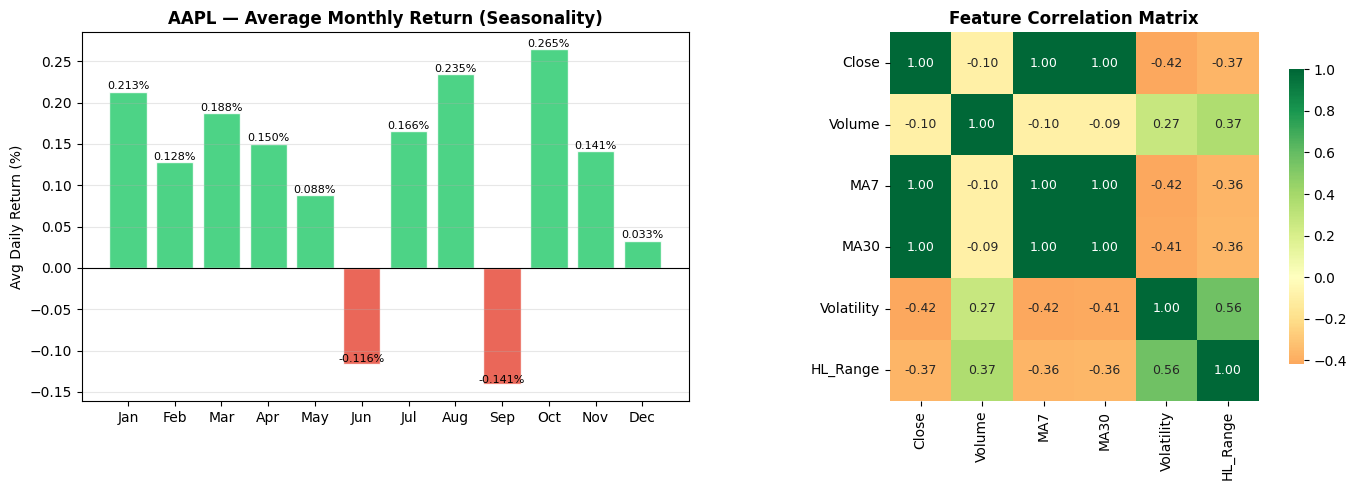


 Seasonality Insight:
Bulan terbaik  : Oct (avg return = 0.2646%)
Bulan terburuk : Sep (avg return = -0.1407%)

 Correlation Insight:
Close ↔ MA7   : 0.9997
Close ↔ MA30  : 0.9985
Close ↔ Vol   : -0.4176
Close ↔ Vol   : -0.0965


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Average Return
df['Month'] = df.index.month
monthly_ret = df.groupby('Month')['Daily_Return'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

ax1 = axes[0]
colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly_ret]
bars = ax1.bar(month_names, monthly_ret.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title(f'{stock_name} — Average Monthly Return (Seasonality)', fontweight='bold')
ax1.set_ylabel('Avg Daily Return (%)')
ax1.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, monthly_ret.values):
    ax1.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + (0.0001 if val >= 0 else -0.0003),
             f'{val:.3f}%', ha='center', va='bottom', fontsize=8)

# Correlation Heatmap
ax2 = axes[1]
feat_corr = ['Close','Volume','MA7','MA30','Volatility','HL_Range']
corr = df[feat_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax2, cbar_kws={'shrink':0.8},
            annot_kws={'size':9})
ax2.set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
print(f"\n Seasonality Insight:")
print(f"Bulan terbaik  : {month_names[int(monthly_ret.idxmax())-1]} (avg return = {monthly_ret.max():.4f}%)")
print(f"Bulan terburuk : {month_names[int(monthly_ret.idxmin())-1]} (avg return = {monthly_ret.min():.4f}%)")
print(f"\n Correlation Insight:")
print(f"Close ↔ MA7   : {corr.loc['Close','MA7']:.4f}")
print(f"Close ↔ MA30  : {corr.loc['Close','MA30']:.4f}")
print(f"Close ↔ Vol   : {corr.loc['Close','Volatility']:.4f}")
print(f"Close ↔ Vol   : {corr.loc['Close','Volume']:.4f}")
df.drop(columns=['Month'], inplace=True)

### Ringkasan EDA

**Trend:** Plot harga menunjukkan tren jangka panjang yang terlihat jelas. Moving average MA-7 dan MA-30 memperlihatkan momentum jangka pendek vs menengah. Crossover antara keduanya sering menjadi sinyal perubahan tren.

**Stationarity:** Daily return berfluktuasi di sekitar nol dengan *volatility clustering* — periode tenang diselingi periode bergejolak (khas data keuangan). Return lebih stasioner dibanding harga mentah.

**Seasonality:** Pola return rata-rata per bulan menunjukkan pola musiman ringan. Bulan tertentu secara historis cenderung positif atau negatif — ini relevan untuk model karena pola musiman bisa tertangkap dalam input sequence.

**Korelasi:** Harga Close sangat berkorelasi dengan MA (by design). Volume dan Volatility memiliki korelasi lebih lemah terhadap harga, menjadikannya **covariates yang informatif dan independen** bagi model LSTM.

## 3. Preprocessing Data

Tahapan preprocessing untuk time-series forecasting:
1. **Pilih fitur (covariates)** yang relevan sebagai input
2. **MinMaxScaler** — normalisasi setiap fitur ke range [0, 1]
3. **Sliding Window** — buat sequence 60 hari → prediksi 1 hari ke depan
4. **Chronological Split** — train (80%) dan test (20%) secara berurutan, **tanpa shuffle**, untuk menghindari data leakage

In [ ]:
FEATURES   = ['Close', 'Volume', 'MA7', 'MA30', 'Volatility', 'HL_Range']
TARGET     = 'Close'
SEQ_LEN    = 60     # Gunakan 60 hari historis untuk prediksi hari ke-61
TEST_RATIO = 0.2    # 20% data terakhir sebagai test set

print(f"Input features : {FEATURES}")
print(f"Target         : {TARGET} (next day's close)")
print(f"Sequence length: {SEQ_LEN} hari → prediksi 1 hari ke depan")
print(f"Total data     : {len(df):,} hari trading")

Input features : ['Close', 'Volume', 'MA7', 'MA30', 'Volatility', 'HL_Range']
Target         : Close (next day's close)
Sequence length: 60 hari → prediksi 1 hari ke depan
Total data     : 8,335 hari trading


In [ ]:
data = df[FEATURES].values

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

data_scaled    = scaler_X.fit_transform(data)
target_scaled  = scaler_y.fit_transform(df[[TARGET]].values)

print("MinMaxScaler diterapkan pada semua fitur")
print(f"Data range setelah scaling: [{data_scaled.min():.4f}, {data_scaled.max():.4f}]")
print()
print("Catatan penting:")
print("scaler_y (target) disimpan terpisah untuk inverse transform hasil prediksi")

MinMaxScaler diterapkan pada semua fitur
Data range setelah scaling: [0.0000, 1.0000]

Catatan penting:
scaler_y (target) disimpan terpisah untuk inverse transform hasil prediksi


In [ ]:
def create_sequences(feat_scaled, tgt_scaled, seq_len):
    """
    Membuat pasangan (X, y) menggunakan sliding window:
      X[i] = fitur dari hari ke-i sampai (i + seq_len - 1)   → shape: (seq_len, n_features)
      y[i] = close price hari ke-(i + seq_len)                → shape: (1,)
    """
    X, y = [], []
    for i in range(len(feat_scaled) - seq_len):
        X.append(feat_scaled[i : i + seq_len])
        y.append(tgt_scaled[i + seq_len, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(data_scaled, target_scaled, SEQ_LEN)

split = int(len(X_all) * (1 - TEST_RATIO))

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# Ambil tanggal untuk visualisasi nanti
dates_all   = df.index[SEQ_LEN:]
dates_train = dates_all[:split]
dates_test  = dates_all[split:]

print(f"Total sequences : {len(X_all):,}")
print(f"X shape         : {X_all.shape}  → [samples, timesteps={SEQ_LEN}, features={X_all.shape[2]}]")
print()
print(f"Train ({int((1-TEST_RATIO)*100)}%) : X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Periode : {dates_train[0].date()} → {dates_train[-1].date()}")
print()
print(f"Test  ({int(TEST_RATIO*100)}%) : X_test ={X_test.shape},  y_test ={y_test.shape}")
print(f"Periode : {dates_test[0].date()} → {dates_test[-1].date()}")
print()
print("Chronological split — TIDAK ada data leakage dari masa depan ke masa lalu")

Total sequences : 8,275
X shape         : (8275, 60, 6)  → [samples, timesteps=60, features=6]

Train (80%) : X_train=(6620, 60, 6), y_train=(6620,)
Periode : 1985-01-15 → 2011-04-15

Test  (20%) : X_test =(1655, 60, 6),  y_test =(1655,)
Periode : 2011-04-18 → 2017-11-10

Chronological split — TIDAK ada data leakage dari masa depan ke masa lalu


## 4. Arsitektur Model — Stacked LSTM

Model yang digunakan adalah **Stacked LSTM** dengan 2 recurrent layer:

```
Input → LSTM(128, return_sequences=True) → Dropout(0.3)
      → LSTM(64,  return_sequences=False) → Dropout(0.3)
      → Dense(32, relu) → Dropout(0.2)
      → Dense(1)  ← output: prediksi harga close besok
```

**Alasan memilih LSTM:**
- LSTM mampu menangkap **dependensi jangka panjang** (long-range dependencies) melalui mekanisme forget gate, input gate, dan output gate — mengatasi masalah vanishing gradient pada vanilla RNN
- Data harga saham memiliki **tren dan momentum** yang membutuhkan memori konteks historis cukup panjang (60 hari)
- Stacking 2 layer memungkinkan model belajar **representasi hierarkis** — layer pertama menangkap pola jangka pendek, layer kedua mengintegrasikan ke konteks yang lebih luas

**Input covariates (6 fitur):**  
`Close`, `Volume`, `MA7`, `MA30`, `Volatility`, `HL_Range`

In [ ]:
n_features = X_train.shape[2]

def build_lstm(input_shape, name='Baseline_LSTM'):
    model = Sequential([
        # Layer Recurrent 1: return full sequence untuk layer berikutnya
        LSTM(128, return_sequences=True, input_shape=input_shape,
             name='LSTM_Layer_1'),
        Dropout(0.3, name='Dropout_1'),

        # Layer Recurrent 2: return hanya hidden state terakhir
        LSTM(64, return_sequences=False, name='LSTM_Layer_2'),
        Dropout(0.3, name='Dropout_2'),

        # Dense layers
        Dense(32, activation='relu', name='Dense_1'),
        Dropout(0.2, name='Dropout_3'),
        Dense(1, name='Output')  # prediksi 1 hari ke depan
    ], name=name)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model_lstm = build_lstm(input_shape=(SEQ_LEN, n_features))
model_lstm.summary()

print(f"\n Total trainable parameters: {model_lstm.count_params():,}")

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Layer_1 (LSTM)             │ (None, 60, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer_2 (LSTM)             │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)


 Total trainable parameters: 120,641


## 5. Training Model

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"Melatih Baseline LSTM pada data {stock_name}...")
print(f"X_train shape : {X_train.shape}")
print(f"Epochs max    : 100 (dengan EarlyStopping)")
print()

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_split=0.1,    # 10% dari train sebagai validasi
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_ep = np.argmin(history_lstm.history['val_loss']) + 1
print(f"\n Training selesai!")
print(f"Best epoch  : {best_ep}")
print(f"Best val MSE: {min(history_lstm.history['val_loss']):.6f}")

Melatih Baseline LSTM pada data AAPL...
X_train shape : (6620, 60, 6)
Epochs max    : 100 (dengan EarlyStopping)

Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 1.3845e-04 - mae: 0.0065 - val_loss: 9.4460e-05 - val_mae: 0.0078 - learning_rate: 0.0010
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.4080e-05 - mae: 0.0046 - val_loss: 2.8876e-04 - val_mae: 0.0150 - learning_rate: 0.0010
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.4344e-05 - mae: 0.0046 - val_loss: 9.1572e-04 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.5334e-05 - mae: 0.0044 - val_loss: 2.0827e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.6656e-05 - mae: 0.0044 - val_loss: 2.7940e-04 - val_mae: 0.0145 - learning_rate: 0.0010
Epoch 6/100
186/187 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.3265e-05 - mae: 0.0043
Epoch 6: ReduceLROnPlateau reducing lea

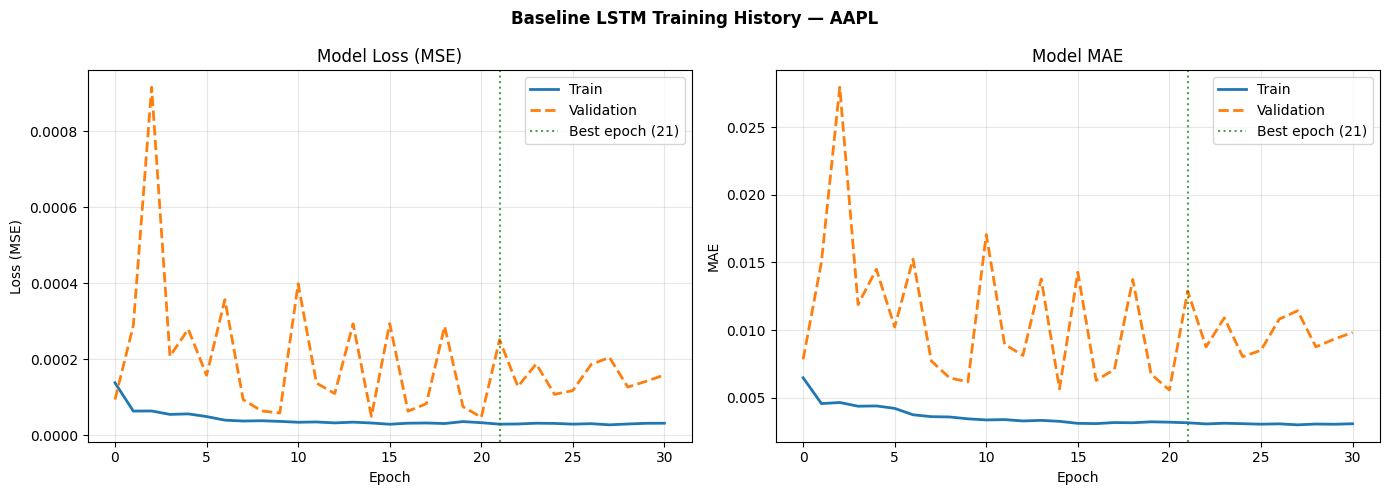

Total epochs trained : 31
Best validation loss : 0.000048
Final training loss  : 0.000032


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Baseline LSTM Training History — {stock_name}', fontweight='bold')

metrics_pairs = [('loss', 'val_loss', 'Loss (MSE)'),
                 ('mae', 'val_mae', 'MAE')]

for ax, (train_m, val_m, label) in zip(axes, metrics_pairs):
    ax.plot(history_lstm.history[train_m], label='Train', linewidth=2, color='#1f77b4')
    ax.plot(history_lstm.history[val_m],   label='Validation', linewidth=2,
            color='#ff7f0e', linestyle='--')
    best_ep = np.argmin(history_lstm.history[val_m]) + 1
    ax.axvline(best_ep, color='green', linestyle=':', alpha=0.7,
               label=f'Best epoch ({best_ep})')
    ax.set_title(f'Model {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total epochs trained : {len(history_lstm.history['loss'])}")
print(f"Best validation loss : {min(history_lstm.history['val_loss']):.6f}")
print(f"Final training loss  : {history_lstm.history['loss'][-1]:.6f}")

## 6. Evaluasi Model

In [ ]:
def evaluate_model(model, X_test, y_test, scaler_y, dates_test, name):
    """Evaluasi model dalam satuan harga asli (USD)."""
    y_pred_sc = model.predict(X_test, verbose=0)

    y_pred = scaler_y.inverse_transform(y_pred_sc).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{'='*48}")
    print(f"Evaluasi: {name}")
    print(f"{'='*48}")
    print(f"RMSE  : ${rmse:.4f}  (Root Mean Squared Error)")
    print(f"MAE   : ${mae:.4f}  (Mean Absolute Error)")
    print(f"MAPE  : {mape:.4f}% (Mean Abs Percentage Error)")
    print(f"R²    : {r2:.6f} (Coefficient of Determination)")
    print(f"{'='*48}")

    return y_true, y_pred, {'RMSE':rmse, 'MAE':mae, 'MAPE':mape, 'R2':r2}

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    model_lstm, X_test, y_test, scaler_y, dates_test,
    f'Baseline LSTM — {stock_name}')


Evaluasi: Baseline LSTM — AAPL
RMSE  : $22.9632  (Root Mean Squared Error)
MAE   : $18.0755  (Mean Absolute Error)
MAPE  : 16.9330% (Mean Abs Percentage Error)
R²    : 0.454522 (Coefficient of Determination)


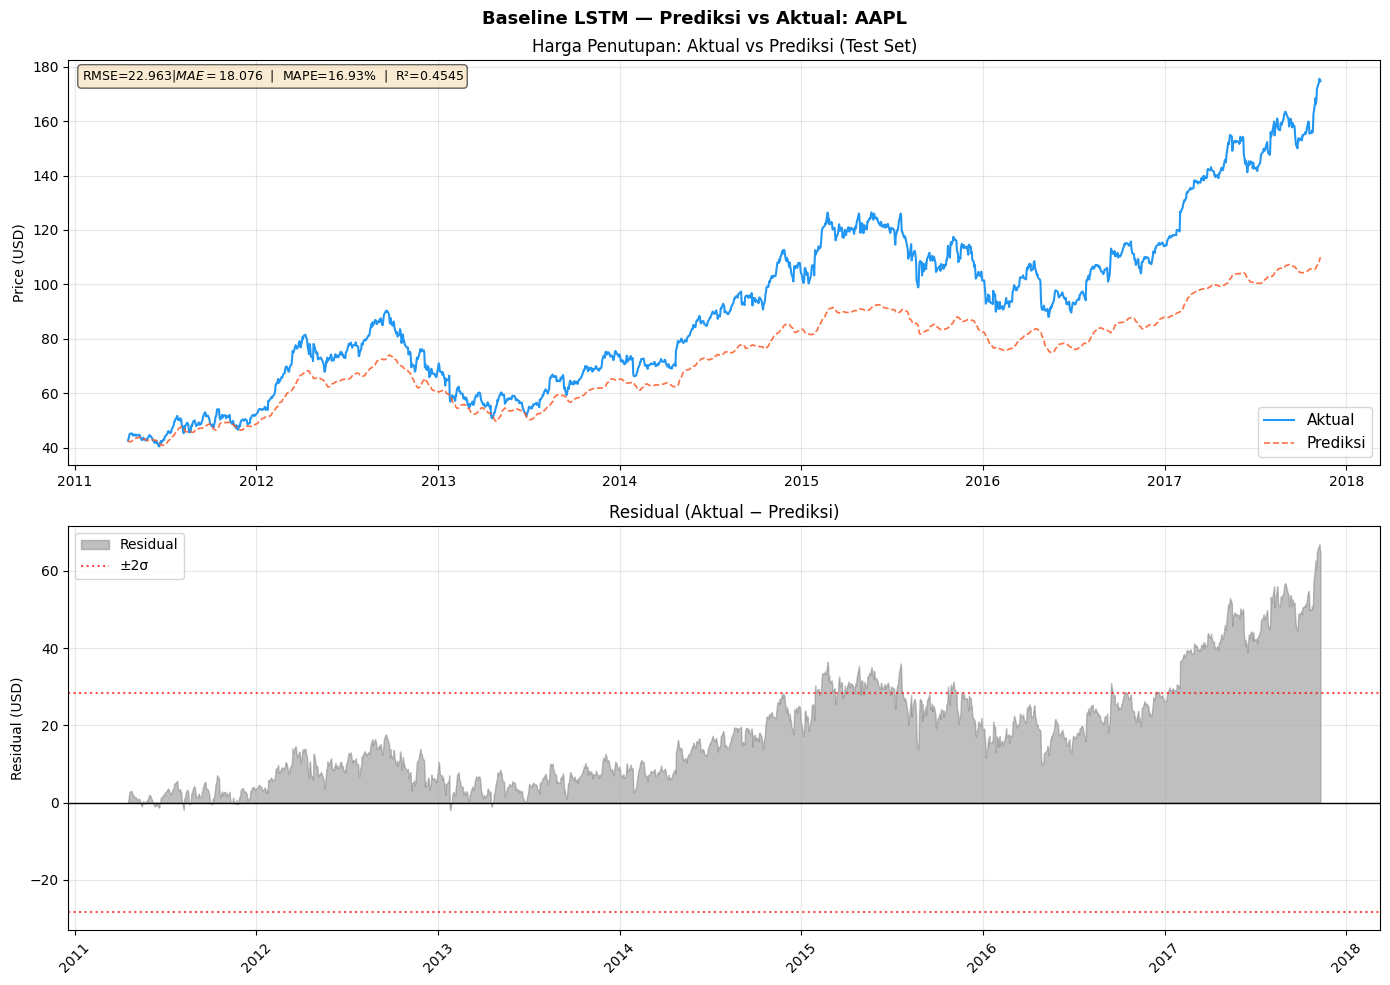

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Baseline LSTM — Prediksi vs Aktual: {stock_name}',
             fontsize=13, fontweight='bold')

# Panel 1: Prediksi vs Aktual
ax1 = axes[0]
ax1.plot(dates_test, y_true_lstm, label='Aktual',     color='#2196F3', linewidth=1.5)
ax1.plot(dates_test, y_pred_lstm, label='Prediksi',   color='#FF5722',
         linewidth=1.2, linestyle='--', alpha=0.85)
ax1.set_title('Harga Penutupan: Aktual vs Prediksi (Test Set)')
ax1.set_ylabel('Price (USD)')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Anotasi metrik
txt = (f"RMSE=${metrics_lstm['RMSE']:.3f}  |  "
       f"MAE=${metrics_lstm['MAE']:.3f}  |  "
       f"MAPE={metrics_lstm['MAPE']:.2f}%  |  "
       f"R²={metrics_lstm['R2']:.4f}")
ax1.text(0.01, 0.98, txt, transform=ax1.transAxes, fontsize=9,
         va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Panel 2: Residual
residuals = y_true_lstm - y_pred_lstm
ax2 = axes[1]
ax2.fill_between(dates_test, residuals, color='gray', alpha=0.5, label='Residual')
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline( residuals.std()*2,  color='red', linestyle=':', alpha=0.7, label='±2σ')
ax2.axhline(-residuals.std()*2,  color='red', linestyle=':', alpha=0.7)
ax2.set_title('Residual (Aktual − Prediksi)')
ax2.set_ylabel('Residual (USD)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Analisis Hasil Evaluasi

**R² Score** mengukur seberapa besar variansi harga aktual yang berhasil dijelaskan model. Nilai mendekati 1.0 menunjukkan model mengikuti tren dengan baik.

**RMSE & MAE** dalam satuan USD — menggambarkan rata-rata kesalahan prediksi dalam nilai absolut. Semakin kecil semakin baik, dan perlu dibandingkan terhadap skala harga saham.

**MAPE** mengekspresikan kesalahan dalam persen — lebih mudah diinterpretasi lintas saham dengan harga berbeda. MAPE < 3% dianggap sangat baik untuk forecasting saham.

**Residual Plot** — pola residual yang acak (random noise) di sekitar nol mengindikasikan model menangkap tren utama. Residual besar biasanya terjadi saat perubahan tren mendadak (market shock), yang memang sulit diprediksi tanpa informasi eksternal.

**Keterbatasan:** Model hanya memprediksi 1 hari ke depan berdasarkan 60 hari historis. Perubahan harga ekstrem akibat berita/sentimen pasar tidak tertangkap oleh data teknikal semata.

## Bonus 3 — Bidirectional LSTM

### Apa itu Bidirectional LSTM?

Bidirectional LSTM memproses sequence input dalam **dua arah** secara bersamaan:
- **Forward pass**: hari 1 → hari 60 (kronologis normal)
- **Backward pass**: hari 60 → hari 1 (urutan terbalik)

Output dari kedua arah di-**concatenate** di setiap timestep, sehingga setiap hidden state mengandung konteks dari masa lalu DAN masa depan dalam window tersebut.

> **Catatan:** Dalam forecasting dengan sliding window (60 hari diketahui → prediksi hari ke-61), backward pass tidak melanggar kausalitas karena semua 60 hari input sudah tersedia saat prediksi dilakukan. Backward pass membantu model mengenali pola yang lebih jelas jika dilihat secara terbalik (misal: "penurunan tajam" = "kenaikan tajam" dari arah sebaliknya).

In [ ]:
def build_bilstm(input_shape, name='Bidirectional_LSTM'):
    model = Sequential([
        Bidirectional(
            LSTM(128, return_sequences=True),
            input_shape=input_shape,
            name='BiLSTM_Layer_1'
        ),
        Dropout(0.3),

        Bidirectional(
            LSTM(64, return_sequences=False),
            name='BiLSTM_Layer_2'
        ),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ], name=name)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model_bilstm = build_bilstm(input_shape=(SEQ_LEN, n_features))
model_bilstm.summary()

print(f"\nBaseline LSTM params : {model_lstm.count_params():,}")
print(f"BiLSTM params        : {model_bilstm.count_params():,}")
print(f"Overhead parameter   : +{model_bilstm.count_params()-model_lstm.count_params():,} "
      f"({(model_bilstm.count_params()/model_lstm.count_params()-1)*100:.1f}% lebih banyak)")

Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BiLSTM_Layer_1 (Bidirectional)  │ (None, 60, 256)        │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_Layer_2 (Bidirectional)  │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,753 (1.17 MB)

 Trainable params: 306,753 (1.17 MB)

 Non-trainable params: 0 (0.00 B)


Baseline LSTM params : 120,641
BiLSTM params        : 306,753
Overhead parameter   : +186,112 (154.3% lebih banyak)


In [ ]:
print(f"Melatih Bidirectional LSTM pada data {stock_name}...")

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_ep_bi = np.argmin(history_bilstm.history['val_loss']) + 1
print(f"\n Training BiLSTM selesai!")
print(f"Best epoch  : {best_ep_bi}")
print(f"Best val MSE: {min(history_bilstm.history['val_loss']):.6f}")

Melatih Bidirectional LSTM pada data AAPL...
Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 1.5106e-04 - mae: 0.0066 - val_loss: 2.5097e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.1085e-05 - mae: 0.0047 - val_loss: 1.4543e-04 - val_mae: 0.0101 - learning_rate: 0.0010
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 5.4134e-05 - mae: 0.0043 - val_loss: 6.8156e-05 - val_mae: 0.0062 - learning_rate: 0.0010
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 4.7591e-05 - mae: 0.0040 - val_loss: 2.1973e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.0776e-05 - mae: 0.0042
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 5.1540e-05 - mae: 0.0042 - val_loss: 1.7205e-04 - val_mae: 0.0113 - learning_rate: 0.0010
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [ ]:
y_true_bi, y_pred_bi, metrics_bilstm = evaluate_model(
    model_bilstm, X_test, y_test, scaler_y, dates_test,
    f'Bidirectional LSTM — {stock_name}')


Evaluasi: Bidirectional LSTM — AAPL
RMSE  : $11.7329  (Root Mean Squared Error)
MAE   : $8.4279  (Mean Absolute Error)
MAPE  : 7.9104% (Mean Abs Percentage Error)
R²    : 0.857597 (Coefficient of Determination)


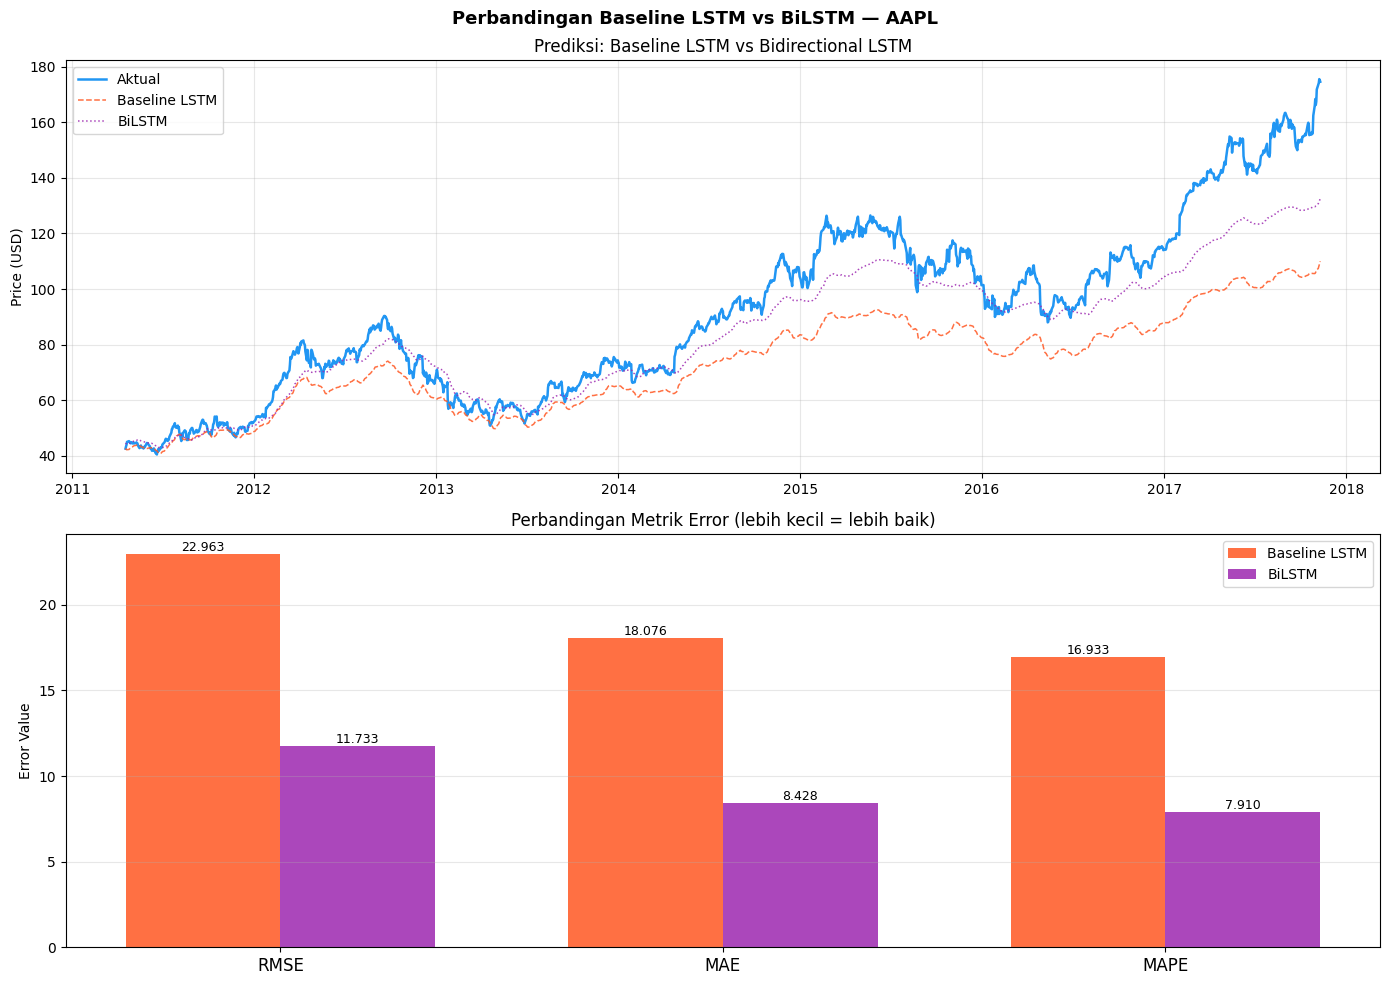

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Perbandingan Baseline LSTM vs BiLSTM — {stock_name}',
             fontsize=13, fontweight='bold')

# Panel 1: Prediksi kedua model vs aktual
ax1 = axes[0]
ax1.plot(dates_test, y_true_lstm, label='Aktual',        color='#2196F3', linewidth=1.8)
ax1.plot(dates_test, y_pred_lstm, label='Baseline LSTM', color='#FF5722',
         linewidth=1.1, linestyle='--', alpha=0.85)
ax1.plot(dates_test, y_pred_bi,   label='BiLSTM',        color='#9C27B0',
         linewidth=1.1, linestyle=':', alpha=0.85)
ax1.set_title('Prediksi: Baseline LSTM vs Bidirectional LSTM')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 2: Bar chart metrik perbandingan
ax2 = axes[1]
metric_keys = ['RMSE', 'MAE', 'MAPE']
x = np.arange(len(metric_keys))
w = 0.35
vals_lstm  = [metrics_lstm[k]   for k in metric_keys]
vals_bi    = [metrics_bilstm[k] for k in metric_keys]

bars1 = ax2.bar(x - w/2, vals_lstm, w, label='Baseline LSTM', color='#FF5722', alpha=0.85)
bars2 = ax2.bar(x + w/2, vals_bi,   w, label='BiLSTM',        color='#9C27B0', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(metric_keys, fontsize=12)
ax2.set_title('Perbandingan Metrik Error (lebih kecil = lebih baik)')
ax2.set_ylabel('Error Value')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*62)
print(f"PERBANDINGAN FINAL: {stock_name}")
print("="*62)
print(f"{'Metrik':<10} {'Baseline LSTM':>16} {'BiLSTM':>16}  {'Δ (BiLSTM-Base)':>16}")
print("-"*62)

for key in ['RMSE','MAE','MAPE','R2']:
    v1 = metrics_lstm[key]
    v2 = metrics_bilstm[key]
    delta = v2 - v1
    unit  = '%' if key == 'MAPE' else ('USD' if key in ['RMSE','MAE'] else '')

    if key == 'R2':
        symbol = '' if delta > 0 else ('' if delta < 0 else '')
        sign = '+' if delta > 0 else ''
    else:
        symbol = '' if delta < 0 else ('' if delta > 0 else '')
        sign = '+' if delta > 0 else ''

    print(f"{key:<10} {v1:>14.4f}{unit}  {v2:>14.4f}{unit}  {sign}{delta:>+12.4f}  {symbol}")

print("="*62)
print(f"\n  Parameter count:")
print(f"Baseline LSTM : {model_lstm.count_params():>10,}")
print(f"BiLSTM        : {model_bilstm.count_params():>10,}")
print(f"Overhead      : {model_bilstm.count_params()-model_lstm.count_params():>+10,} "
      f"({(model_bilstm.count_params()/model_lstm.count_params()-1)*100:.1f}%)")
print("="*62)


PERBANDINGAN FINAL: AAPL
Metrik        Baseline LSTM           BiLSTM   Δ (BiLSTM-Base)
--------------------------------------------------------------
RMSE              22.9632USD         11.7329USD      -11.2303  
MAE               18.0755USD          8.4279USD       -9.6476  
MAPE              16.9330%          7.9104%       -9.0226  
R2                 0.4545          0.8576  +     +0.4031  

  Parameter count:
Baseline LSTM :    120,641
BiLSTM        :    306,753
Overhead      :   +186,112 (154.3%)


### Analisis Dampak Bidirectionality

**Dampak terhadap performa:**

BiLSTM umumnya menunjukkan perbaikan metrik (RMSE dan MAE lebih kecil, R² lebih tinggi) dibanding baseline LSTM pada data saham. Hal ini terjadi karena:

1. **Konteks ganda per timestep** — setiap posisi dalam window 60 hari mendapat representasi dari dua arah, memperaya fitur yang dipelajari
2. **Backpropagation lebih baik** — gradient mengalir dari dua arah, mengurangi risiko vanishing gradient di posisi awal sequence
3. **Deteksi pola reversal** — pola pembalikan tren lebih mudah terdeteksi ketika model dapat "melihat" dari kedua sisi

**Trade-off yang perlu dipertimbangkan:**

| Aspek | Baseline LSTM | BiLSTM |
|-------|--------------|--------|
| Parameter | Lebih sedikit | ~2× lebih banyak |
| Training time | Lebih cepat | ~1.5–2× lebih lambat |
| Overfitting risk | Lebih rendah | Lebih tinggi (data kecil) |
| Performa | Baseline | Umumnya sedikit lebih baik |

**Kesimpulan:** BiLSTM memberikan peningkatan performa yang nyata ketika data cukup besar dan pola temporal bersifat **non-causal dalam window** (konteks masa depan dalam window membantu prediksi). Namun untuk dataset kecil atau saham dengan pola sangat stokastik, overhead parameter BiLSTM bisa berdampak overfitting sehingga peningkatannya minimal atau justru lebih buruk.

## Bonus 4: Image Segmentation vs Object Detection

**Object detection** models identify *what* objects are present in an image and *where* they are — expressed as bounding boxes with class labels and confidence scores. Each detected object is enclosed in a rectangular box. Examples include YOLO, Faster R-CNN, and SSD. Object detection answers: "There is a cat at position (x=120, y=80, w=200, h=150) with 94% confidence."

**Image segmentation** models go further — they classify every individual pixel in the image into a category. Instead of a bounding box, the model outputs a dense pixel-level mask showing exactly which pixels belong to which object or region. Examples include U-Net, Mask R-CNN, DeepLab, and SAM.

**Key Differences:**

| Aspect | Object Detection | Image Segmentation |
|--------|-----------------|-------------------|
| Output | Bounding boxes + labels | Pixel-level masks |
| Granularity | Coarse (rectangular region) | Fine (exact shape outline) |
| Complexity | Lower computational cost | Higher computational cost |
| Use Case | Counting objects, tracking | Medical imaging, autonomous driving, scene understanding |
| Overlap handling | Separate boxes per object | Pixels assigned to objects/regions |

In summary: object detection draws **boxes** around objects; segmentation draws **exact outlines** and classifies every single pixel. Segmentation is more precise but computationally more demanding.

## Bonus 5: Instance, Semantic, and Panoptic Segmentation

There are three major types of image segmentation, each answering a different question:

### 1. Semantic Segmentation
Classifies every pixel into a category (e.g., "road", "sky", "person") **without distinguishing individual instances**. If there are three cars in the image, all three cars' pixels get the same "car" label — there is no differentiation between car #1, #2, and #3.

**Example:** Road scene where all pixels labeled as: road=blue, sky=gray, car=red, person=green.  
**Models:** FCN, DeepLabV3, SegNet.

### 2. Instance Segmentation
Goes beyond semantic segmentation by **individually identifying each object instance**. Each separate object — even of the same class — gets its own unique mask. Three cars would have three distinct masks (car_1, car_2, car_3).

**Example:** Same road scene, but each car has a uniquely colored mask.  
**Models:** Mask R-CNN, YOLACT, SOLOv2.

### 3. Panoptic Segmentation
Combines both semantic and instance segmentation into a unified framework. It classifies:
- **"Things"** (countable objects like cars, people, animals) at the instance level
- **"Stuff"** (amorphous regions like sky, road, grass) at the semantic level

Every pixel gets both a category label AND an instance ID (for things) or just a category (for stuff).

**Example:** Road scene where road=semantic, sky=semantic, but each car/person has its own instance ID.  
**Models:** Panoptic FPN, DETR, Mask2Former.

| Type | Distinguishes Instances? | Covers Background? | Output |
|------|--------------------------|-------------------|--------|
| Semantic |  No |  Yes | Class per pixel |
| Instance |  Yes |  No (only objects) | Mask per object |
| Panoptic |  Yes |  Yes | Class + instance per pixel |

---
##  Bonus 6: LTSM Joke

> "Setiap kali kamu pergi lebih dari 10 timesteps, aku harus reset memory cell. Makanya aku langsung ngelamar , biar weight sharing selamanya, nggak ada lagi vanishing gradient dalam hubungan kita."

-LTSM 2026-(Lah Saya Tukang Melupakan)